# Análisis exploratorio de incidencia delictiva en México

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('data/delitos.csv')

#### Ejercicio 1: Elige 3 estados de la república y grafica una serie de tiempo de la frecuencia abosluta de homicidios dolosos de enero 2015 a julio 2019 en estas tres entidades

In [8]:
print(df.columns)
print(df['entidad'].unique())

Index(['anio', 'clave_ent', 'entidad', 'tipo_de_delito', 'nombre_mes', 'fecha',
       'frecuencia'],
      dtype='object')
['Aguascalientes' 'Baja California' 'Baja California Sur' 'Campeche'
 'Coahuila de Zaragoza' 'Colima' 'Chiapas' 'Chihuahua' 'Ciudad de México'
 'Durango' 'Guanajuato' 'Guerrero' 'Hidalgo' 'Jalisco' 'México'
 'Michoacán de Ocampo' 'Morelos' 'Nayarit' 'Nuevo León' 'Oaxaca' 'Puebla'
 'Querétaro' 'Quintana Roo' 'San Luis Potosí' 'Sinaloa' 'Sonora' 'Tabasco'
 'Tamaulipas' 'Tlaxcala' 'Veracruz de Ignacio de la Llave' 'Yucatán'
 'Zacatecas']


/tmp/ipykernel_8697/1467315187.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['mes_num'] = df_filtrado['nombre_mes'].str.lower().map(meses)
/tmp/ipykernel_8697/1467315187.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['fecha'] = pd.to_datetime(df_filtrado['anio'].astype(str) + '-' + df_filtrado['mes_num'].astype(str).str.zfill(2), format='%Y-%m')


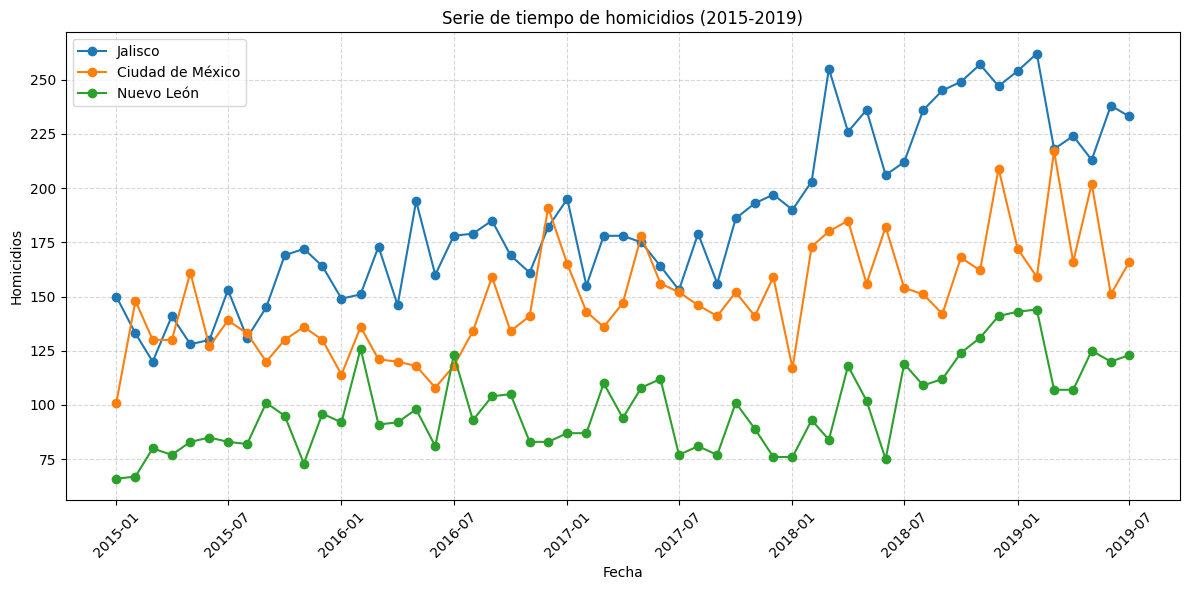

In [14]:
# Serie de tiempo de homicidios en 3 estados de enero 2015 a julio 2019
estados = ['Jalisco', 'Ciudad de México', 'Nuevo León']  # Usa los nombres exactos de df['entidad'].unique()
df_filtrado = df[(df['entidad'].isin(estados)) & (df['tipo_de_delito'] == 'Homicidio')]
# Mapeo de nombres de meses a números
meses = {
    'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
    'julio': 7, 'agosto': 8, 'septiembre': 9, 'octubre': 10, 'noviembre': 11, 'diciembre': 12
}
# Aplica el mapeo
df_filtrado['mes_num'] = df_filtrado['nombre_mes'].str.lower().map(meses)
# Crea la columna de fecha correctamente
df_filtrado['fecha'] = pd.to_datetime(df_filtrado['anio'].astype(str) + '-' + df_filtrado['mes_num'].astype(str).str.zfill(2), format='%Y-%m')
# Filtra el rango de fechas solicitado
df_filtrado = df_filtrado[(df_filtrado['fecha'] >= '2015-01-01') & (df_filtrado['fecha'] <= '2019-07-31')]
# Ordena por fecha
df_filtrado = df_filtrado.sort_values(['entidad', 'fecha'])
if not df_filtrado.empty:
    plt.figure(figsize=(12,6))
    for estado in estados:
        datos_estado = df_filtrado[df_filtrado['entidad'] == estado]
        plt.plot(datos_estado['fecha'], datos_estado['frecuencia'], marker='o', label=estado)
    plt.xlabel('Fecha')
    plt.ylabel('Homicidios')
    plt.title('Serie de tiempo de homicidios (2015-2019)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron datos para los filtros seleccionados.')

#### Ejercicio 2: Contesta las siguientes  preguntas:
1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
2. ¿Cuantos robos de vehículo automotor ha habido en el 2019?
3. Obten la suma de homicidos dolosos y feminidios en toda la República Mexicana en cada año.
4. ¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?
5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?

In [16]:
# 1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
homicidios_colima_2018 = df[(df['entidad'] == 'Colima') & (df['anio'] == 2018) & (df['tipo_de_delito'] == 'Homicidio')]['frecuencia'].sum()
print(f"Homicidios dolosos en Colima en 2018: {homicidios_colima_2018}")

# 2. ¿Cuantos robos de vehículo automotor ha habido en el 2019?
robos_vehiculo_2019 = df[(df['anio'] == 2019) & (df['tipo_de_delito'] == 'Robo de vehículo automotor')]['frecuencia'].sum()
print(f"Robos de vehículo automotor en 2019: {robos_vehiculo_2019}")

# 3. Suma de homicidios dolosos y feminicidios en toda la República Mexicana en cada año
suma_hom_fem = df[df['tipo_de_delito'].isin(['Homicidio', 'Feminicidio'])].groupby(['anio','tipo_de_delito'])['frecuencia'].sum().unstack(fill_value=0)
print("Suma anual de homicidios dolosos y feminicidios:")
print(suma_hom_fem)

# 4. ¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?
print('Columnas disponibles:', df.columns)
# Intenta encontrar el nombre correcto de la columna municipio
municipio_col = None
for col in df.columns:
    if 'mun' in col.lower():
        municipio_col = col
        break
if municipio_col:
    fem_max = df[df['tipo_de_delito'] == 'Feminicidio'].sort_values('frecuencia', ascending=False).iloc[0]
    print(f"Mayor número de feminicidios: {fem_max['frecuencia']} en {fem_max['nombre_mes']} ({fem_max['anio']}) en municipio {fem_max[municipio_col]}")
else:
    print('No se encontró una columna de municipio en el DataFrame.')

# 5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?
fem_estado_max = df[df['tipo_de_delito'] == 'Feminicidio'].groupby(['anio','entidad'])['frecuencia'].sum().reset_index().sort_values('frecuencia', ascending=False).iloc[0]
print(f"Mayor feminicidio anual/estado: {fem_estado_max['frecuencia']} en {fem_estado_max['entidad']} ({fem_estado_max['anio']})")

Homicidios dolosos en Colima en 2018: 726.0
Robos de vehículo automotor en 2019: 0.0
Suma anual de homicidios dolosos y feminicidios:
tipo_de_delito  Feminicidio  Homicidio
anio                                  
2015                  413.0    31331.0
2016                  608.0    35410.0
2017                  744.0    41324.0
2018                  899.0    44486.0
2019                  944.0    44878.0
2020                  947.0    43276.0
2021                  981.0    43979.0
2022                  961.0    42884.0
2023                  832.0    42014.0
2024                  401.0    21906.0
Columnas disponibles: Index(['anio', 'clave_ent', 'entidad', 'tipo_de_delito', 'nombre_mes', 'fecha',
       'frecuencia'],
      dtype='object')
No se encontró una columna de municipio en el DataFrame.
Mayor feminicidio anual/estado: 151.0 en México (2020)


#### Ejercicio 3: Haz una gráfica de pastel de tipos de delito. Deberás crear una gráfica para cada año. Utilzia la función subplots de matplotlib

/tmp/ipykernel_8697/1479528088.py:11: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


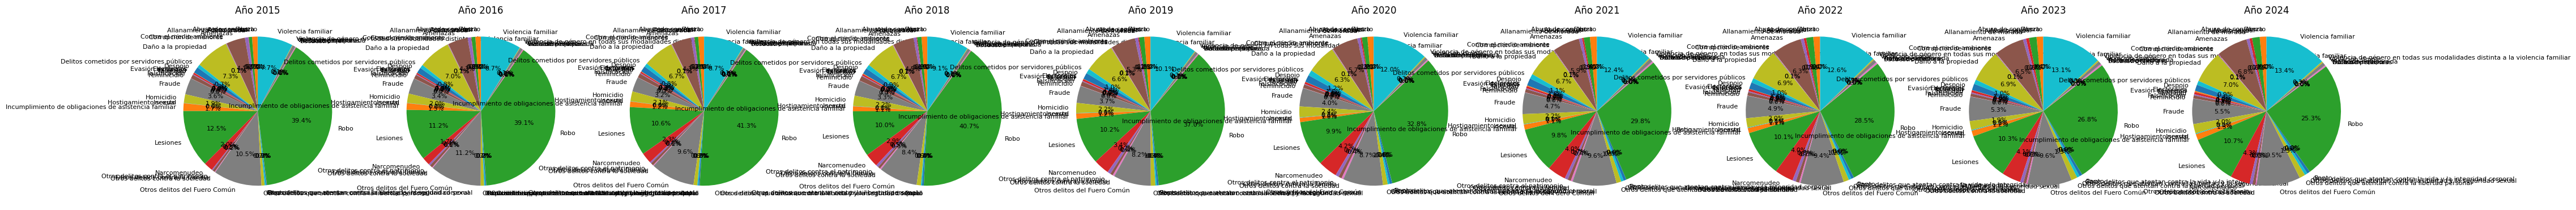

In [17]:
# Gráfica de pastel de tipos de delito por año usando subplots
anios = sorted(df['anio'].unique())
tipos = df['tipo_de_delito'].unique()
n = len(anios)
fig, axes = plt.subplots(1, n, figsize=(5*n, 6))
for i, anio in enumerate(anios):
    ax = axes[i] if n > 1 else axes
    datos = df[df['anio'] == anio].groupby('tipo_de_delito')['frecuencia'].sum()
    ax.pie(datos, labels=datos.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
    ax.set_title(f'Año {anio}')
plt.tight_layout()
plt.show()

---
#### Calcula la tasa por 100,000 habitantes
##### Tasa por 100,000 habitantes
Mostrar el total de delitos en una entidad no nos sirve de mucho. Es mucho más útil calcular la tasa de incidencia delictiva por cada 100,000 habitantes

$$
tasa = \frac{delitos\space totales}{población} \times 100,000
$$

Esta tasa la podemos anualizar multiplicándola por un factor de 12
$$
tasa\space anualizada = tasa \times 12
$$

Población por entidad federativa según [la encuesta intercensal 2015](https://www.inegi.org.mx/programas/intercensal/2015/)

No tienes que descargar nada. Ya están los datos en la carpeta data

In [18]:
pobs = pd.read_csv('data/poblacion_entidades_2015.csv', encoding='iso-8859-1', sep=";")
pobs = pobs[['Cve_Entidad', 'Entidad', 'Poblacion']]
pobs = pobs.rename(columns={'Cve_Entidad':'clave_entidad', 'Entidad':'entidad', 'Poblacion':'poblacion'})
pobs.head()

,clave_entidad,entidad,poblacion
0,1,Aguascalientes,1312544.0
1,2,Baja California,3315766.0
2,3,Baja California Sur,712029.0
3,4,Campeche,899931.0
4,5,Coahuila de Zaragoza,5217908.0
